In [1]:
import pathlib
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pingouin as pg
import statsmodels.formula.api as smf


import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u

sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42

%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/fig4_reward_overrep_sparse')
figdir.mkdir(exist_ok=True, parents=True)

{'date': '21_11_2024', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 8, 'novel_arm': -1, 'exp_day': 6}
{'date': '31_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'exp_day': 6}
{'date': '31_05_2025', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 6, 'novel_arm': -1, 'exp_day': 6}
{'date': '31_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 6, 'novel_arm': 1, 'exp_day': 6}
{'date': '03_06_2025', 'scene': 'YMaze_LNovel', 'session': 4, 'scan': 10, 'novel_arm': 1, 'exp_day': 6}
{'date': '29_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 20, 'novel_arm': 1, 'exp_day': 6}
{'date': '30_05_2025', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 37, 'novel_arm': -1, 'exp_day': 6}


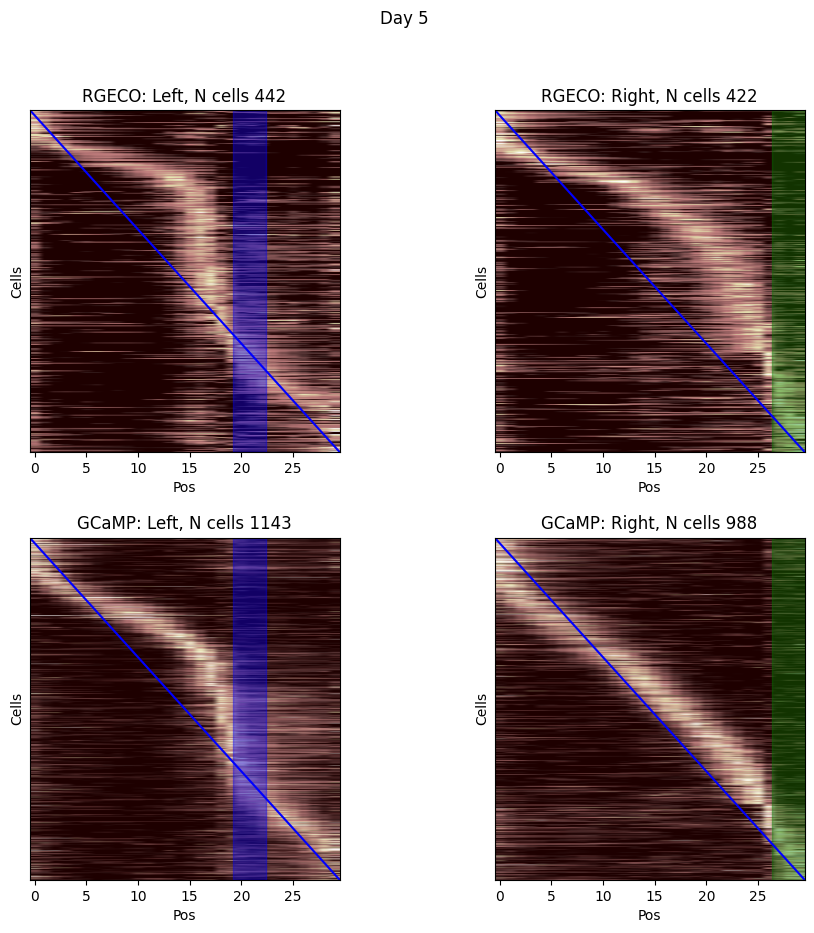

In [3]:
fig,ax = stx.reward_overrep.plot_leftright_crossval_placecells_withinday_sparse(5, ts_key = 'F_dff')
fig.savefig(figdir / "population_day5.pdf")
            

In [4]:
frac_cls = stx.reward_overrep.PeriRewardCellFrac_Sparse(sparse_mice, 
                                                        np.arange(6), 
                                                        place_cell_only=True,
                                                        ts_key='F_dff')

{'date': '16_11_2024', 'scene': 'YMaze_LNovel', 'session': 4, 'scan': 14, 'novel_arm': -1, 'exp_day': 1}


{'date': '17_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 25, 'novel_arm': -1, 'exp_day': 2}
{'date': '18_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 18, 'novel_arm': -1, 'exp_day': 3}
{'date': '19_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'exp_day': 4}
{'date': '20_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 12, 'novel_arm': -1, 'exp_day': 5}
{'date': '21_11_2024', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 8, 'novel_arm': -1, 'exp_day': 6}
{'date': '26_05_2025', 'scene': 'YMaze_LNovel', 'session': 4, 'scan': 7, 'novel_arm': 1, 'exp_day': 1}
{'date': '27_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 23, 'novel_arm': 1, 'exp_day': 2}
{'date': '28_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 25, 'novel_arm': 1, 'exp_day': 3}
{'date': '29_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 1, 'novel_arm': 1, 'exp_day': 4}
{'date': '30_05_2025', 'scene': 'YMaze_LNovel', 'session': 3, '

/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/reward_overrep.py:169: RuntimeWarning: Mean of empty slice
  avg_mat = np.nanmean(sess.trial_matrices[f'{chan}_{ts_key}'][trial_mask,:,:],axis=0)
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/reward_overrep.py:178: RuntimeWarning: invalid value encountered in scalar divide
  reward_frac = reward_cells.sum().astype(float)/float(reward_cells.shape[0])


{'date': '26_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 20, 'novel_arm': 1, 'exp_day': 3}
{'date': '27_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 22, 'novel_arm': 1, 'exp_day': 4}
{'date': '28_05_2025', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 16, 'novel_arm': 1, 'exp_day': 5}
{'date': '29_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 20, 'novel_arm': 1, 'exp_day': 6}
{'date': '25_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'exp_day': 1}
{'date': '26_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 14, 'novel_arm': -1, 'exp_day': 2}
{'date': '28_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'exp_day': 4}
{'date': '29_05_2025', 'scene': 'YMaze_LNovel', 'session': 3, 'scan': 14, 'novel_arm': -1, 'exp_day': 5}
{'date': '30_05_2025', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 37, 'novel_arm': -1, 'exp_day': 6}


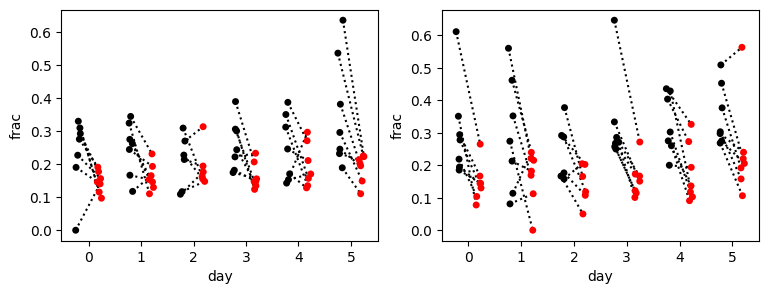

In [5]:
df = frac_cls.df

fig,ax = plt.subplots(1,2, figsize=[9,3])
for i, nov in enumerate(('fam','nov')):
    ax[i] = sns.stripplot(data=df.loc[df['ttype']==nov,:],
                x='day',
                y='frac',
                hue='chan', 
                hue_order=('channel_1', 'channel_0'), 
                palette=['black', 'red'],
                dodge=True,
                ax=ax[i],
                legend=False)


    for d in range(0,12,2):
        for (x0, y0), (x1, y1) in zip(ax[i].collections[d].get_offsets(), ax[i].collections[d+1].get_offsets()):
            ax[i].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)


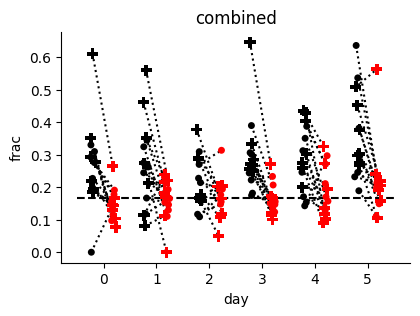

In [6]:
fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)
df_mu = frac_cls.df.groupby(['mouse','day','chan','ttype'])['frac'].mean().reset_index()
sns.stripplot(data=df_mu.loc[df_mu['ttype']=='fam',:],
            x='day',
            y='frac',
            hue='chan', 
            hue_order=('channel_1', 'channel_0'), 
            palette=['black', 'red'],
            dodge=True,
            ax=ax, s= 5,
            legend=False)

sns.stripplot(data=df_mu.loc[df_mu['ttype']=='nov',:],
            x='day',
            y='frac',
            hue='chan', 
            hue_order=('channel_1', 'channel_0'), 
            palette=['black', 'red'],
            marker='P',
            s=8,
            alpha=1.,
            dodge=True,
            ax=ax,
            legend=False)

for d in range(0,24,2):
        for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
            ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

ax.set_title('combined')


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.hlines(5./30, -.5,5.5, linestyle='--', color='black')

fig.savefig( figdir / 'frac_per_day_combined.pdf', bbox_inches='tight')

In [7]:
df = frac_cls.df.copy()
df['rank_frac'] = df['frac'].rank()


df['mouse'] = df['mouse'].astype('category')
# df = df.dropna()

mdl = smf.mixedlm('rank_frac ~ C(chan) * C(day) * C(ttype)', df, groups = df["mouse"])
res = mdl.fit()
res.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                             Mixed Linear Model Regression Results
===============================================================================================
Model:                          MixedLM              Dependent Variable:              rank_frac
No. Observations:               164                  Method:                          REML     
No. Groups:                     7                    Scale:                           1454.1249
Min. group size:                20                   Log-Likelihood:                  -734.4389
Max. group size:                24                   Converged:                       Yes      
Mean group size:                23.4                                                           
-----------------------------------------------------------------------------------------------
                                                  Coef.  Std.Err.   z    P>|z|  [0.025   0.975]
-----------------------------------------------------------------------------------------------
Intercept                                         39.571   14.933  2.650 0.008   10.303  68.840
C(chan)[T.channel_1]                              59.643   20.383  2.926 0.003   19.693  99.593
C(day)[T.1]                                        9.571   20.383  0.470 0.639  -30.378  49.521
C(day)[T.2]                                       31.255   21.253  1.471 0.141  -10.401  72.910
C(day)[T.3]                                       11.857   20.383  0.582 0.561  -28.093  51.807
C(day)[T.4]                                       30.714   20.383  1.507 0.132   -9.236  70.664
C(day)[T.5]                                       29.714   20.383  1.458 0.145  -10.236  69.664
C(ttype)[T.nov]                                   -0.071   20.383 -0.004 0.997  -40.021  39.878
C(chan)[T.channel_1]:C(day)[T.1]                  -9.643   28.826 -0.335 0.738  -66.140  46.855
C(chan)[T.channel_1]:C(day)[T.2]                 -50.976   30.003 -1.699 0.089 -109.781   7.828
C(chan)[T.channel_1]:C(day)[T.3]                  -5.143   28.826 -0.178 0.858  -61.640  51.355
C(chan)[T.channel_1]:C(day)[T.4]                 -33.500   28.826 -1.162 0.245  -89.998  22.998
C(chan)[T.channel_1]:C(day)[T.5]                  -4.357   28.826 -0.151 0.880  -60.855  52.140
C(chan)[T.channel_1]:C(ttype)[T.nov]              13.929   28.826  0.483 0.629  -42.569  70.426
C(day)[T.1]:C(ttype)[T.nov]                       11.071   28.826  0.384 0.701  -45.426  67.569
C(day)[T.2]:C(ttype)[T.nov]                      -26.762   30.003 -0.892 0.372  -85.566  32.043
C(day)[T.3]:C(ttype)[T.nov]                       -5.000   28.826 -0.173 0.862  -61.498  51.498
C(day)[T.4]:C(ttype)[T.nov]                      -13.143   28.826 -0.456 0.648  -69.640  43.355
C(day)[T.5]:C(ttype)[T.nov]                       11.714   28.826  0.406 0.684  -44.783  68.212
C(chan)[T.channel_1]:C(day)[T.1]:C(ttype)[T.nov] -25.643   40.766 -0.629 0.529 -105.543  54.257
C(chan)[T.channel_1]:C(day)[T.2]:C(ttype)[T.nov]  30.155   42.430  0.711 0.477  -53.007 113.317
C(chan)[T.channel_1]:C(day)[T.3]:C(ttype)[T.nov]   9.357   40.766  0.230 0.818  -70.543  89.257
C(chan)[T.channel_1]:C(day)[T.4]:C(ttype)[T.nov]  31.571   40.766  0.774 0.439  -48.328 111.471
C(chan)[T.channel_1]:C(day)[T.5]:C(ttype)[T.nov] -13.286   40.766 -0.326 0.744  -93.185  66.614
Group Var                                        106.874    2.669                              
===============================================================================================

"""

In [8]:
res.wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                                               chi2                 P>chi2  df constraint
Intercept                      [[7.02196828582555]]   0.008051567602772307              1
C(chan)                       [[8.562157357533541]]  0.0034322245972037233              1
C(day)                        [[4.234058878961693]]     0.5162327113503281              5
C(ttype)                 [[1.2280336129017275e-05]]     0.9972039540796014              1
C(chan):C(day)                [[4.581608705482746]]     0.4690392747985519              5
C(chan):C(ttype)            [[0.23347989065238817]]     0.6289554613120367              1
C(day):C(ttype)              [[2.4412934822337258]]     0.7853092605251707              5
C(chan):C(day):C(ttype)       [[3.087379363122619]]     0.6865164727102508              5

Shapiro-Wilk: W=0.987, p=0.135
D'Agostino: χ²=5.861, p=0.0534


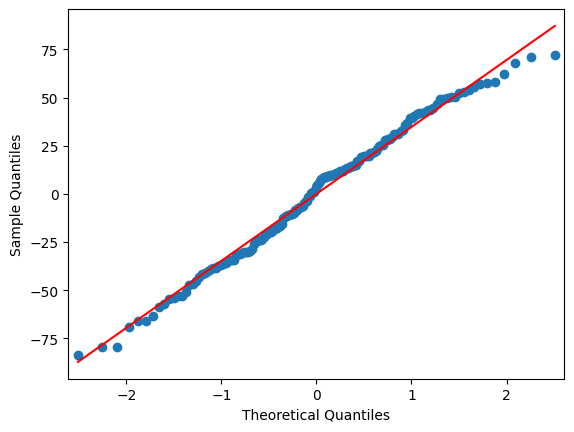

In [9]:
import statsmodels.api as sm
from scipy.stats import shapiro, normaltest, anderson
fig = sm.qqplot(res.resid, line ='s')

# Shapiro-Wilk test (good for small–moderate n)
shapiro_test = shapiro(res.resid)
print(f"Shapiro-Wilk: W={shapiro_test.statistic:.3f}, p={shapiro_test.pvalue:.3g}")

# D’Agostino and Pearson omnibus test (good for larger n)
dagostino_test = normaltest(res.resid)
print(f"D'Agostino: χ²={dagostino_test.statistic:.3f}, p={dagostino_test.pvalue:.3g}")

In [15]:
import pickle
with open('/home/mplitt/shuffle_pkls/sparse_pc_frac_mixedlm_shuffle.pkl', 'rb') as file:
        model_shuff_results = pickle.load(file)

for stat in model_shuff_results.keys():

    true_coef = model_shuff_results[stat]['genotype coef.']
    shuff_coefs = model_shuff_results[stat]['shuffle genotype coef.']
    print('nans', np.isnan(shuff_coefs).sum())
    p = (true_coef<shuff_coefs).sum()/float(shuff_coefs.shape[0])
    p = np.minimum(p, 1-p)
    print(f"{stat} true coef = {true_coef}, p = {p} ")

nans 50
rzone_bool true coef = 0.08606332879216182, p = 0.0 
nans 66
rank_frac true coef = 59.71428571428539, p = 0.0 


In [16]:
model_shuff_results['rank_frac']['true_model'].wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                                               chi2                 P>chi2  df constraint
Intercept                     [[6.753686730823667]]   0.009355417778946032              1
C(chan)                       [[8.670489892275096]]  0.0032340424056624116              1
C(day)                         [[4.26996693648243]]     0.5112374492192262              5
C(ttype)                 [[1.2405980134813421e-05]]     0.9971896869232857              1
C(chan):C(day)                [[4.634208289890478]]    0.46213003503526917              5
C(chan):C(ttype)             [[0.2334557341762412]]     0.6289732086512003              1
C(day):C(ttype)              [[3.1957804531760403]]      0.669831442175868              5
C(chan):C(day):C(ttype)      [[3.8269138726136798]]     0.5745956084440771              5

In [11]:
res = pg.pairwise_tests(data = df, within=['ttype', 'chan'], dv='frac', subject='mouse',
                        parametric=False, padjust='holm')

res

,Contrast,ttype,A,B,Paired,Parametric,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,ttype,-,fam,nov,True,False,10.0,two-sided,0.578125,NaN,NaN,-0.405681
1,chan,-,channel_0,channel_1,True,False,0.0,two-sided,0.015625,NaN,NaN,-2.253676
2,ttype * chan,fam,channel_0,channel_1,True,False,1.0,two-sided,0.031250,0.03125,holm,-1.366623
3,ttype * chan,nov,channel_0,channel_1,True,False,0.0,two-sided,0.015625,0.03125,holm,-1.622326


In [12]:
res = pg.pairwise_tests(data = df, within=['day', 'chan'], dv='frac', subject='mouse',
                        parametric=False, padjust='holm')

res

,Contrast,day,A,B,Paired,Parametric,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,day,-,0,1,True,False,9.0,two-sided,0.84375,1.00000,holm,0.182963
1,day,-,0,2,True,False,8.0,two-sided,0.68750,1.00000,holm,0.360681
2,day,-,0,3,True,False,10.0,two-sided,1.00000,1.00000,holm,0.095443
3,day,-,0,4,True,False,7.0,two-sided,0.56250,1.00000,holm,-0.075429
4,day,-,0,5,True,False,4.0,two-sided,0.21875,1.00000,holm,-0.907921
5,day,-,1,2,True,False,5.0,two-sided,0.31250,1.00000,holm,0.151419
6,day,-,1,3,True,False,10.0,two-sided,1.00000,1.00000,holm,-0.147802
7,day,-,1,4,True,False,4.0,two-sided,0.21875,1.00000,holm,-0.307144
8,day,-,1,5,True,False,1.0,two-sided,0.06250,0.87500,holm,-1.187327
9,day,-,2,3,True,False,8.0,two-sided,0.68750,1.00000,holm,-0.511869


r=-0.07, p=0.384


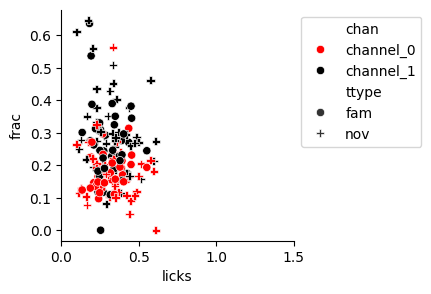

In [14]:
fig, ax = plt.subplots(figsize=[3,3])
sns.scatterplot(data=frac_cls.df,
                x='licks',
                y='frac',
                hue='chan',
                style='ttype',
                markers={'fam':'o', 'nov':'P'},
                alpha=1.,
                palette = {'channel_0':'red', 'channel_1':'black'},
                ax=ax, 
                )
sns.move_legend(ax, "upper left", bbox_to_anchor=(1,1))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim([0,1.5])
fig.savefig(figdir / 'licks_vs_reward_frac.pdf', bbox_inches='tight')


r,p = sp.stats.spearmanr(frac_cls.df['licks'], frac_cls.df['frac'])
print(f'r={r:.2f}, p={p:.3f}')

In [48]:
reward_cells = stx.reward_overrep.RewardCells_Sparse()

SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09


In [49]:
shuff_df = reward_cells.build_summary_df_for_shuffles()
red_df = shuff_df.groupby(['mouse', 'chan', 'day']).mean().reset_index()
red_df['rank_frac'] = red_df['rzone_bool'].rank()

model = smf.mixedlm(f"rank_frac ~ C(chan) * C(day) ", red_df, groups=red_df["mouse"])
model_result = model.fit()
model_result.summary()


<class 'statsmodels.iolib.summary2.Summary'>
"""
                    Mixed Linear Model Regression Results
=============================================================================
Model:                    MixedLM        Dependent Variable:        rank_frac
No. Observations:         82             Method:                    REML     
No. Groups:               7              Scale:                     218.1728 
Min. group size:          10             Log-Likelihood:            -305.7990
Max. group size:          12             Converged:                 Yes      
Mean group size:          11.7                                               
-----------------------------------------------------------------------------
                                  Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                         17.857    7.183  2.486 0.013   3.778 31.936
C(chan)[T.channel_1]              31.143    7.895  3.945 0.000  15.668 46.617
C(day)[T.1]                        6.857    7.895  0.869 0.385  -8.617 22.332
C(day)[T.2]                        9.248    8.248  1.121 0.262  -6.918 25.414
C(day)[T.3]                       10.143    7.895  1.285 0.199  -5.332 25.617
C(day)[T.4]                        9.000    7.895  1.140 0.254  -6.474 24.474
C(day)[T.5]                       21.571    7.895  2.732 0.006   6.097 37.046
C(chan)[T.channel_1]:C(day)[T.1]  -2.286   11.166 -0.205 0.838 -24.170 19.598
C(chan)[T.channel_1]:C(day)[T.2]  -2.560   11.622 -0.220 0.826 -25.337 20.218
C(chan)[T.channel_1]:C(day)[T.3]  -8.857   11.166 -0.793 0.428 -30.741 13.027
C(chan)[T.channel_1]:C(day)[T.4]   3.929   11.166  0.352 0.725 -17.956 25.813
C(chan)[T.channel_1]:C(day)[T.5]  -2.857   11.166 -0.256 0.798 -24.741 19.027
Group Var                        143.029    6.640                            
=============================================================================

"""

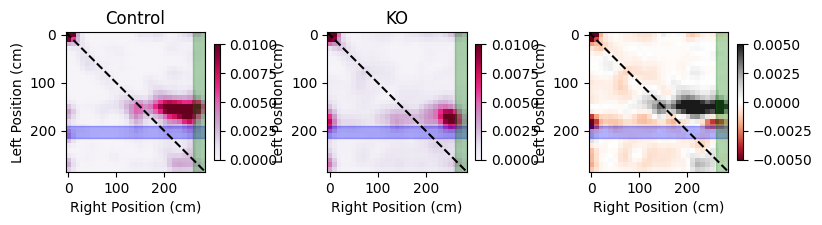

In [50]:
fig, ax = reward_cells.plot_heatmaps(5, vmax=.01, diff_max=.005)
fig.savefig(figdir / "reward_cells_day5_hist.pdf")

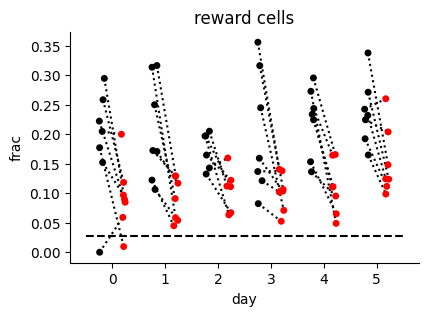

In [51]:
fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)

sns.stripplot(data=reward_cells.summary_df,
            x='day',
            y='frac',
            hue='chan', 
            hue_order=('channel_1', 'channel_0'), 
            palette=['black', 'red'],
            dodge=True,
            ax=ax,
            legend=False)
for d in range(0,12,2):
        for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
            ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)


# sns.pointplot(data=reward_cells.summary_df,
#             x='day',
#             y='frac',
#             errorbar=None,
#             hue='chan',
#             hue_order = ['channel_0', 'channel_1'],
#             dodge = .4,
#             palette = ['red','black'],
#             ax=ax,
#             linestyles="none",
#             marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
#             )
ax.set_title('reward cells')


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.hlines((5/30)**2, -.5,5.5, linestyle='--', color='black')

fig.savefig( figdir / 'reward_cells_per_day.pdf', bbox_inches='tight')

In [45]:
with open('/home/mplitt/shuffle_pkls/sparse_rewardcell_mixedlm_shuffle.pkl', 'rb') as file:
        model_shuff_results = pickle.load(file)

for stat in model_shuff_results.keys():

    true_coef = model_shuff_results[stat]['genotype coef.']
    shuff_coefs = model_shuff_results[stat]['shuffle genotype coef.']
    print('nans', np.isnan(shuff_coefs).sum())
    p = (true_coef<shuff_coefs).sum()/float(shuff_coefs.shape[0])
    p = np.minimum(p, 1-p)
    print(f"{stat} true coef = {true_coef}, p = {p} ")

nans 0
rzone_bool true coef = 0.09334047958060848, p = 0.0 
nans 0
rank_frac true coef = 31.1428571428572, p = 0.0 


In [46]:
model_shuff_results['rank_frac']['true_model'].summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                    Mixed Linear Model Regression Results
=============================================================================
Model:                    MixedLM        Dependent Variable:        rank_frac
No. Observations:         82             Method:                    REML     
No. Groups:               7              Scale:                     218.1728 
Min. group size:          10             Log-Likelihood:            -305.7990
Max. group size:          12             Converged:                 Yes      
Mean group size:          11.7                                               
-----------------------------------------------------------------------------
                                  Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                         17.857    7.183  2.486 0.013   3.778 31.936
C(chan)[T.channel_1]              31.143    7.895  3.945 0.000  15.668 46.617
C(day)[T.1]                        6.857    7.895  0.869 0.385  -8.617 22.332
C(day)[T.2]                        9.248    8.248  1.121 0.262  -6.918 25.414
C(day)[T.3]                       10.143    7.895  1.285 0.199  -5.332 25.617
C(day)[T.4]                        9.000    7.895  1.140 0.254  -6.474 24.474
C(day)[T.5]                       21.571    7.895  2.732 0.006   6.097 37.046
C(chan)[T.channel_1]:C(day)[T.1]  -2.286   11.166 -0.205 0.838 -24.170 19.598
C(chan)[T.channel_1]:C(day)[T.2]  -2.560   11.622 -0.220 0.826 -25.337 20.218
C(chan)[T.channel_1]:C(day)[T.3]  -8.857   11.166 -0.793 0.428 -30.741 13.027
C(chan)[T.channel_1]:C(day)[T.4]   3.929   11.166  0.352 0.725 -17.956 25.813
C(chan)[T.channel_1]:C(day)[T.5]  -2.857   11.166 -0.256 0.798 -24.741 19.027
Group Var                        143.029    6.640                            
=============================================================================

"""

In [47]:
model_shuff_results['rank_frac']['true_model'].wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                                  chi2                 P>chi2  df constraint
Intercept        [[6.179772166336666]]   0.012921891451046448              1
C(chan)         [[15.559091939147358]]  7.996615921281817e-05              1
C(day)           [[7.817987497364432]]     0.1665560878426117              5
C(chan):C(day)  [[1.3989100659902212]]     0.9244324627493846              5